In [16]:
# ============================================================
# Time-frequency plot (Power)
# ============================================================

import numpy as np
import pickle
import matplotlib.pyplot as plt
import mat73

# ============================================================
# Load files
# ============================================================
with open(
    "/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Code/TFdecoding/Results/trf_response_full.pkl",
    "rb",
) as file:
    results = pickle.load(file)

subject_group = mat73.loadmat(
    "/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Data/Behavior/subject_index.mat"
)["subject_index"]

group_indices = {
    "Control": np.where(subject_group == 1)[0],
    "Depressed": np.where(subject_group == 2)[0],
    "Suicidal": np.where(subject_group == 3)[0],
    "All": np.arange(len(subject_group)),
}

# ============================================================
# Parameters
# ============================================================
sfreq = 250
# freqs = np.logspace(np.log10(3), np.log10(60), 40)
freqs = np.logspace(np.log10(6), np.log10(60), 50)

tmin, tmax = -0.2, 1.0
times = np.arange(int(np.round(tmin * sfreq)), int(np.round(tmax * sfreq))) / sfreq

channel_names = [
    "Left frontal",
    "Mid frontal",
    "Right frontal",
    "Left central",
    "Mid central",
    "Right central",
    "Left parietal",
    "Mid parietal",
    "Right parietal",
]

toi_names = ["Biography", "Action", "Reflection", "Intention", "All"]


def plot_trf_diff_grid(
    data,
    time,
    freqs,
    channel,
    toi_names,
    group_indices,
    channel_names=None,
    cmap="RdBu_r",
    robust_percentile=95,
    figsize=(12, 14),
    save="n",
    save_path=None,
    dpi=300,
):
    """
    Plot 5 x 4 TF difference maps (negative - positive).

    Expected shape:
        data[toi]["positive"] and data[toi]["negative"]
        -> (channel, trial, freq, time, subject)
    """

    n_rows = len(toi_names)
    group_names = list(group_indices.keys())
    n_cols = len(group_names)

    # --------------------------------------------------------
    # Precompute all difference maps
    # --------------------------------------------------------
    diff_maps = {}
    all_diff_values = []

    for toi in toi_names:
        diff_maps[toi] = {}
        for group_name, subj_idx in group_indices.items():
            pos = data[toi]["positive"][channel, :, :, subj_idx].mean(axis=(0))
            neg = data[toi]["negative"][channel, :, :, subj_idx].mean(axis=(0))
            diff = neg - pos

            diff_maps[toi][group_name] = diff
            all_diff_values.append(diff.ravel())

    all_diff_values = np.concatenate(all_diff_values)

    # --------------------------------------------------------
    # Shared symmetric color scale
    # --------------------------------------------------------
    vmax = np.percentile(np.abs(all_diff_values), robust_percentile)
    vmin = -vmax

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    if n_rows == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    im = None

    for i, toi in enumerate(toi_names):
        for j, group_name in enumerate(group_names):
            ax = axes[i, j]

            im = ax.imshow(
                diff_maps[toi][group_name],
                aspect="auto",
                origin="lower",
                extent=[time[0], time[-1], freqs[0], freqs[-1]],
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation="nearest",
            )

            if i == 0:
                ax.set_title(group_name, fontsize=12, fontweight="bold")

            if j == 0:
                ax.set_ylabel(f"{toi}\n\nFrequency (Hz)", fontsize=14)

            if i == n_rows - 1:
                ax.set_xlabel("Time (s)", fontsize=14)

            ax.axvline(0, color="k", linestyle="--", linewidth=0.8, alpha=0.8)

    # Shared colorbar
    cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02, aspect=40)
    cbar.set_label("Power difference (Negative - Positive)", fontsize=14)

    title = (
        f"TF Power Difference - {channel_names[channel]}"
        if channel_names
        else f"TF Power Difference - Ch {channel}"
    )
    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.03)

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------
    if save.lower() == "y":

        if save_path is None:

            channel_label = (
                channel_names[channel].replace(" ", "_")
                if channel_names
                else f"ch_{channel}"
            )

            save_path = f"TF_diff_{channel_label}.png"

        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    plt.show()

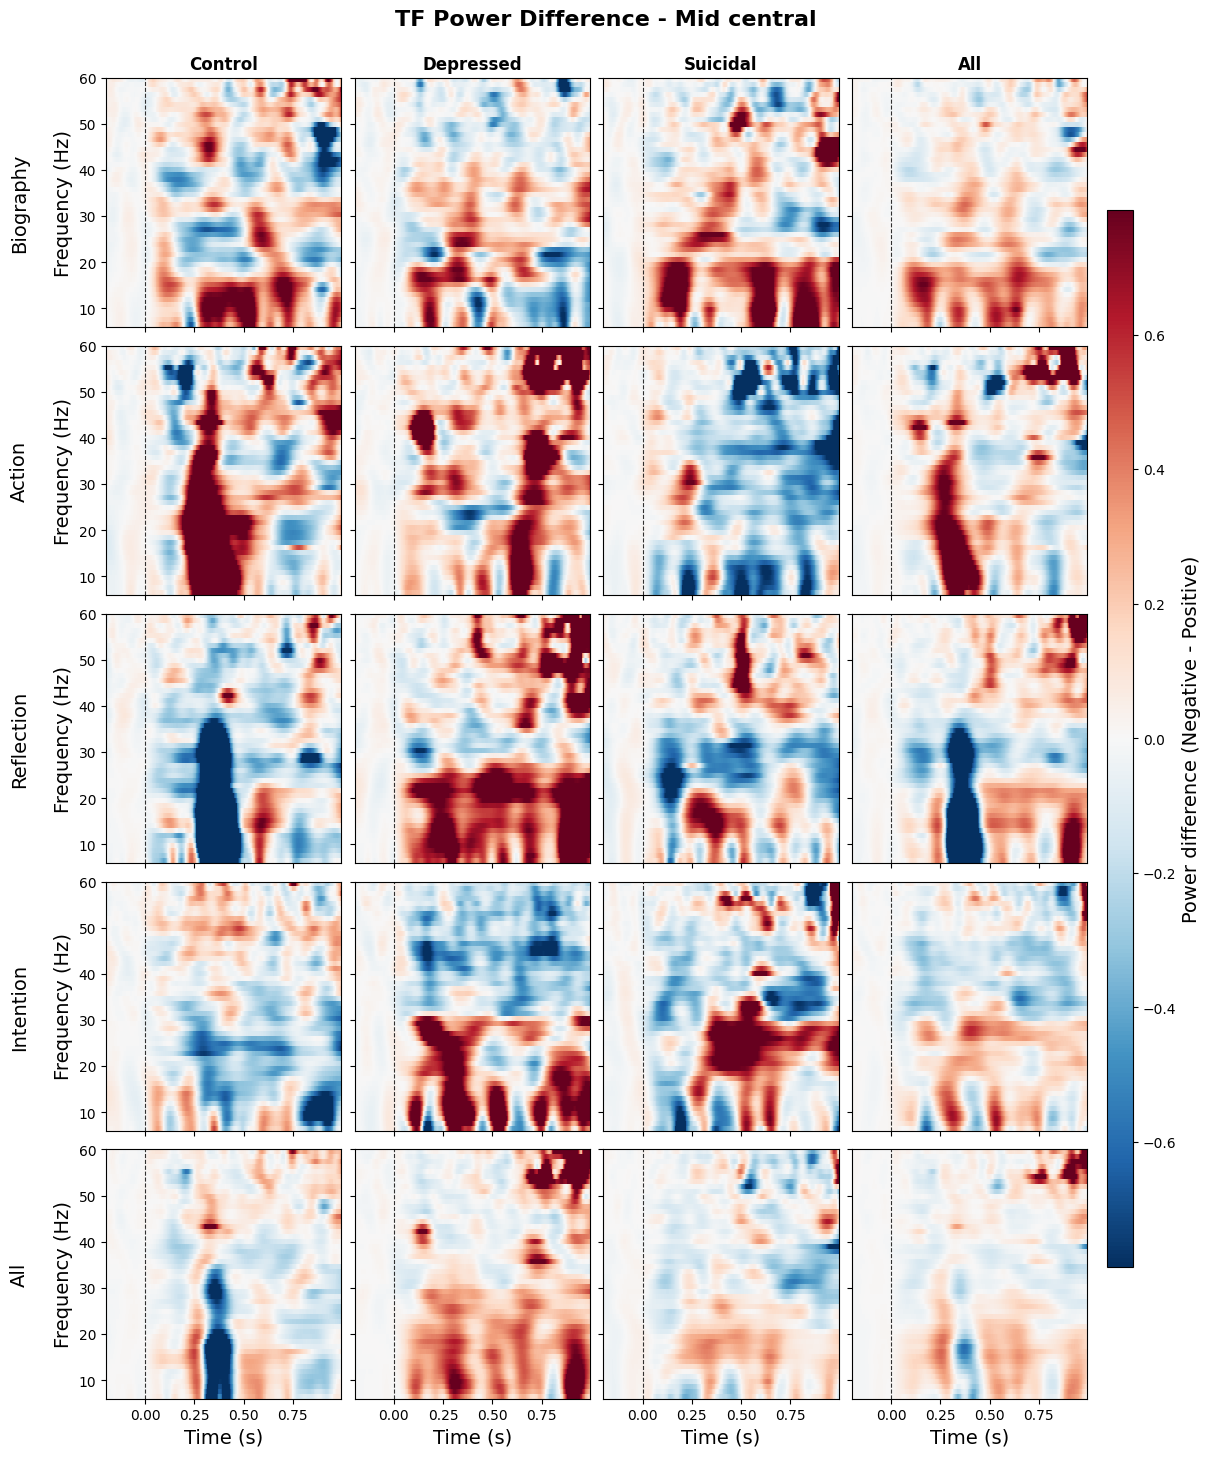

In [17]:
plot_trf_diff_grid(
    data=results,
    time=times,
    freqs=freqs,
    channel=4,
    toi_names=toi_names,
    group_indices=group_indices,
    channel_names=channel_names,
)